> 📝 **Planning note (author use -- remove before publishing)**
>
> **Intended contents:** simple offset correction, linear pressure drift, conductivity/salinity drift-factor correction.

**To do:** fix the SyntaxError from prose sitting in a code cell; write the "where does this reference value actually come from" section (reference CTD cast / bottle samples at deployment+recovery) -- currently just a placeholder note; fix the `dS_end` value/comment mismatch (-0.12 vs "0.03"); finish the trailing "Now lets " sentence; typo cleanup ("deployemtn", "coirrections").

<img src="../../data/images/hiaoos_learning_moored.png" width="300" align="right">

# Postprocessing and QC (Part 2): Drift and offset corrections

> Note: In this notebook, we show examples of correction functions. We won't actually change the input files that we bring into subsequent notebooks. 
>
>

Continuing from the previous notebook (chopping and removing outliers), this notebook covers correcting for sensor drift and offsets:
- Simple case (pressure drift)
- Slightly more complex case (conductivity/salinity drift)

In [41]:
from kval.data import moored, edit
import matplotlib.pyplot as plt
%matplotlib widget

In [13]:
ds = moored.load_nc('../../data/moored_CTD_test_data/intermediate_data/AT800_21_22_CONCERTO_60595_99m_edited.nc', decode_cf=True)

___

## Adjust for a known offset or drift in measured values

***Instrument sensors can drift over time.*** Typically, temperature sensors are quite stable, but pressure sensors and especially conductivity sensors more often experience drift during long deployments. In such cases, it may be necessary to compensate for the drift. 

How to do this compensation is somewhat subjective and often depends on whether other, independent measurements are available to calibrate the instrument - and on your expertise on the study site and sampling configuration.     

>**Note** It is good practice to make any corrections you think will improve the data -  while **indicating clearly in the metadata** very explicitly which corrections you have applied. This way, a user of the data is aware of what you have done and can make their own judgements - and reprocess differently from raw data if they choose. 


In many cases, we have laboratory calibrations of the instrument available both before and after deployment. Often, however, drift in conductivity is due not to the instrument electronics, but external factors like buildup of biological matter within the conductivity cell.

### (Some notes about where we get this from - comparisons with CTD profiles, calibration measurements after deployemtn, etc.)

(Note here too: we wont actually apply these to the dataset. When working, you may want to save the dataset to a new dataset `ctd_daa_after_drift_coirrections.nc` etc

### A simple case: applying a simple offset 

Let's say that we know that our pressure sensor consistently measured 0.8°C warmer than the actual temperature.

In this case, we may want to apply a correction of $-$0.8°C to the `TEMP` time series:

In [14]:
delta_t_add = -0.8
ds_offset_t = moored.offset(ds, 'TEMP', delta_t_add)

This simply adds +0.8 to all data in `TEMP`. If we look at the `TEMP` variable, a note should have been applied to `TEMP`

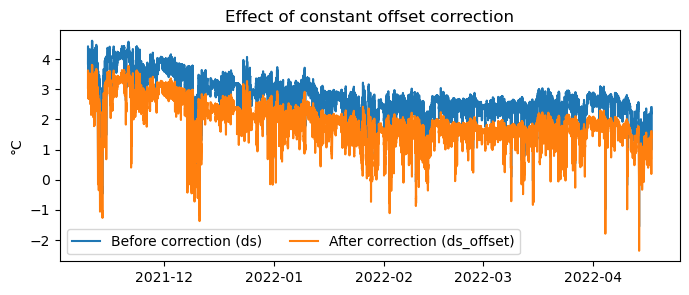

In [17]:
fig, ax = plt.subplots(figsize = (8, 3))
ax.set_title('Effect of constant offset correction')
ax.plot(ds.TIME, ds.TEMP, label = 'Before correction (ds)')
ax.plot(ds_offset_t.TIME, ds_offset_t.TEMP, label = 'After correction (ds_offset)')
ax.legend(ncol = 2)
ax.set_ylabel('°C');


### A simple case: adjusting for a simple pressure drift

Let's continute with pressure as an exaple. Assume that we know that a sensor was measuring correctly on deployment, but there is a known difference `Δp` between instrument and true pressure on recovery. For example, this could be because:
- We have compared instrument pressure around recovery with independent measurements from a different, well-calibrated instrument, or:
- We observe a drift in pressure while we know that the depth was constant.


The following adjusts the pressure to compensate for the offset on recovery - applying a correction that linearly drifts from 0 on deployment `Δp` on recovery.


In [20]:
deltaP = 21
ds_linear_drift_p = moored.linear_drift_offset(ds, 'PRES', end_val = deltaP)

The same can be done for any other variable besides `PRES`. 

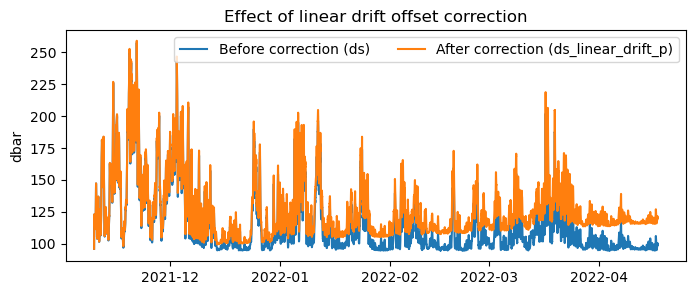

In [23]:
fig, ax = plt.subplots(figsize = (8, 3))
ax.set_title('Effect of linear drift offset correction')
ax.plot(ds.TIME, ds.PRES, label = 'Before correction (ds)')
ax.plot(ds_linear_drift_p.TIME, ds_linear_drift_P.PRES, label = 'After correction (ds_linear_drift_p)')
ax.legend(ncol = 2)
ax.set_ylabel('dbar');


### Compensating for known salinity drift

Salinity is calculated from temperature, pressure and conductivity. If we have drift in salinity this is typically due to a drift in conductivity.

In some cases, we may deem it sufficient to apply a fixed offset of offset drift like we did for pressure above. However,

- It is the conductivity that drifts, we should ideally make corrections to conductivity and then recalculate salinity.
- Conductivity drift corrections should typically be applied as a *factor*, not an offset. I.e. instead of *adding* an evolving offset, we should apply a linearly evolving factor.

For example, lets say that we know initial conductivity (measurements on deployment) were correct, but we ob serve an offset in salinity `ΔS` on recovery. Ideally, we shoudl then:

1. Find the conductivity offset `ΔC` corresponding to the salinity offset `ΔS` at the temperature, salinity and pressure `ΔS` was measured.
2. Find the *factor* `αC` thath we need to multiply our deployment conductivity with in order to correct it to true conductivity.

#### Find the conductivity offset

In [33]:
dS_end = -0.12 # (Made-up) salinity offset. I.e. true salinity of 0.12 higher than measured.
S_end, P_end, T_end = 34.3, 101, 3.3

In [34]:
C_offset, C_factor = edit.cndc_offset_from_psal_offset(dS=dS_end, S=S_end, T=T_end, P=P_end)

In [35]:
print(f'C offset if {C_offset:.4f} mS/cm - corresponding to a factor of {C_factor:.4f}')

C offset if -0.0991 mS/cm - corresponding to a factor of 1.0032


#### Apply correction to `CNDC`

In [36]:
ds_linear_drift_CNDC_factor = moored.linear_drift_factor(ds, 'CNDC', C_factor)

#### Recompute `PSAL` from corrected `CNDC`

In [38]:
ds_linear_drift_CNDC_factor = moored.calculate_PSAL(ds_linear_drift_CNDC_factor)

#### Look at the effects of the correction on `CNDC`

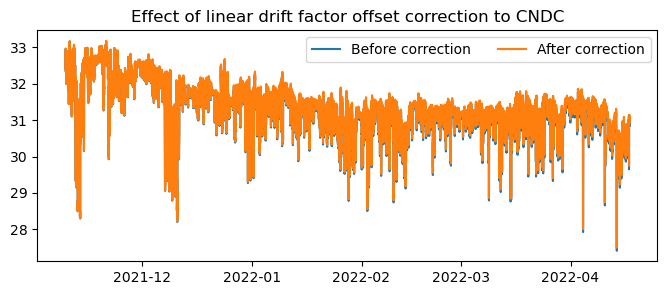

In [37]:
fig, ax = plt.subplots(figsize = (8, 3))
ax.set_title('Effect of linear drift factor offset correction to CNDC')
ax.plot(ds.TIME, ds.CNDC, label = 'Before correction')
ax.plot(ds_linear_drift_CNDC_factor.TIME, ds_linear_drift_CNDC_factor.CNDC, label = 'After correction')
ax.legend(ncol = 2)

#### Look at the effects of the correction on `PSAL`

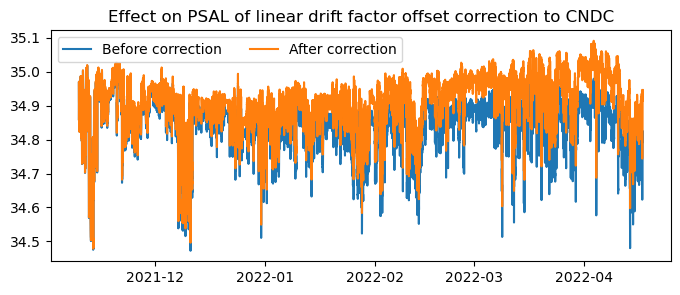

In [40]:
fig, ax = plt.subplots(figsize = (8, 3))
ax.set_title('Effect on PSAL of linear drift factor offset correction to CNDC')
ax.plot(ds.TIME, ds.PSAL, label = 'Before correction')
ax.plot(ds_linear_drift_CNDC_factor.TIME, ds_linear_drift_CNDC_factor.PSAL, label = 'After correction')
ax.legend(ncol = 2)